Handwritten Digit Recognition Using Artificial Neural Network (ANN) on MNIST Dataset

In [ ]:
#Importing Libraries
import tensorflow as tf
import matplotlib.pyplot as plt

In [ ]:
#Splitting the dataset
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
train_images = train_images / 255.0
test_images = test_images / 255.0

In [ ]:
print("Training Images:", train_images.shape)
print("Testing Images:", test_images.shape)
print("Training Labels:", train_labels)

Training Images: (60000, 28, 28)
Testing Images: (10000, 28, 28)
Training Labels: [5 0 4 ... 5 6 8]


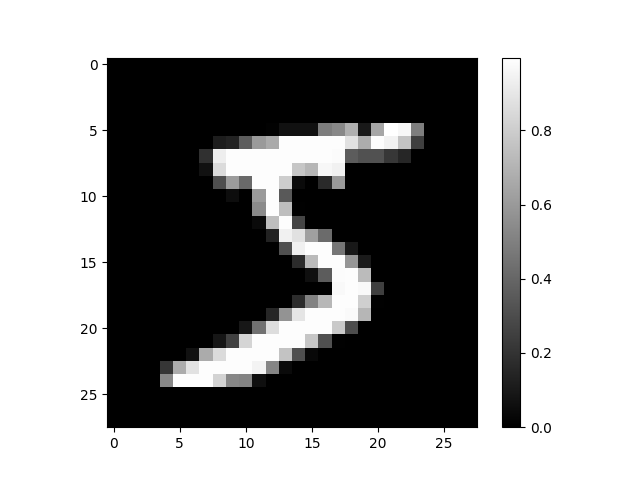

In [ ]:
plt.imshow(train_images[0], cmap='gray')
plt.colorbar()
plt.show()

In [ ]:
#Defining Class Names
class_names = [
    "0",
    "1",
    "2",
    "3",
    "4",
    "5",
    "6",
    "7",
    "8",
    "9"
]
#Displaying the Class Label
print(class_names[train_labels[0]])

5


In [ ]:
# Building the Artificial Neural Network (ANN)
model = tf.keras.models.Sequential()

model.add(tf.keras.layers.Flatten(input_shape=(28,28)))

model.add(tf.keras.layers.Dense(128, activation='relu'))

model.add(tf.keras.layers.Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
# Compiling the Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.fit(
    train_images,
    train_labels,
    epochs=5
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9248 - loss: 0.2643
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9660 - loss: 0.1150
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9761 - loss: 0.0786
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9822 - loss: 0.0576
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9861 - loss: 0.0443


In [ ]:
loss, accuracy = model.evaluate(test_images, test_labels)

print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9757 - loss: 0.0783
Test Accuracy: 0.9757000207901001


In [ ]:
predictions = model.predict(test_images)

print(predictions[0])

print("Predicted:", class_names[predictions[0].argmax()])
print("Actual:", class_names[test_labels[0]])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
['1.28765535e-07', '3.63849182e-08', '2.30786118e-05', '1.70412962e-03', '1.68224920e-10', '3.70854281e-08', '4.84383746e-13', '9.98260915e-01', '1.06618209e-07', '1.16331312e-05']
Predicted: 7
Actual: 7


In [ ]:
model.save("mnist_model.keras")